# Dự án FER13 – Nhận diện cảm xúc khuôn mặt (phân tích theo template)



## 1. Định nghĩa vấn đề
- **Bài toán**: phân loại ảnh xám 48×48 thành **7 cảm xúc** – Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral (đa lớp).
- **Dữ liệu** (từ `processing_data` trong `utils.py`): `fer2013.csv`, cột `pixels` (chuỗi 2304 số), `emotion` (0–6), `Usage` → tách sẵn **Training 28 709 / PublicTest 3 589 / PrivateTest 3 589** ảnh. Dự án dùng *PublicTest* làm **valid** và *PrivateTest* làm **test**.
- **Thước đo**: Accuracy; vì lớp lệch mạnh nên cần xem thêm recall từng lớp (confusion matrix).

## 2. Phân tích dữ liệu

Biểu đồ phân phối lớp 

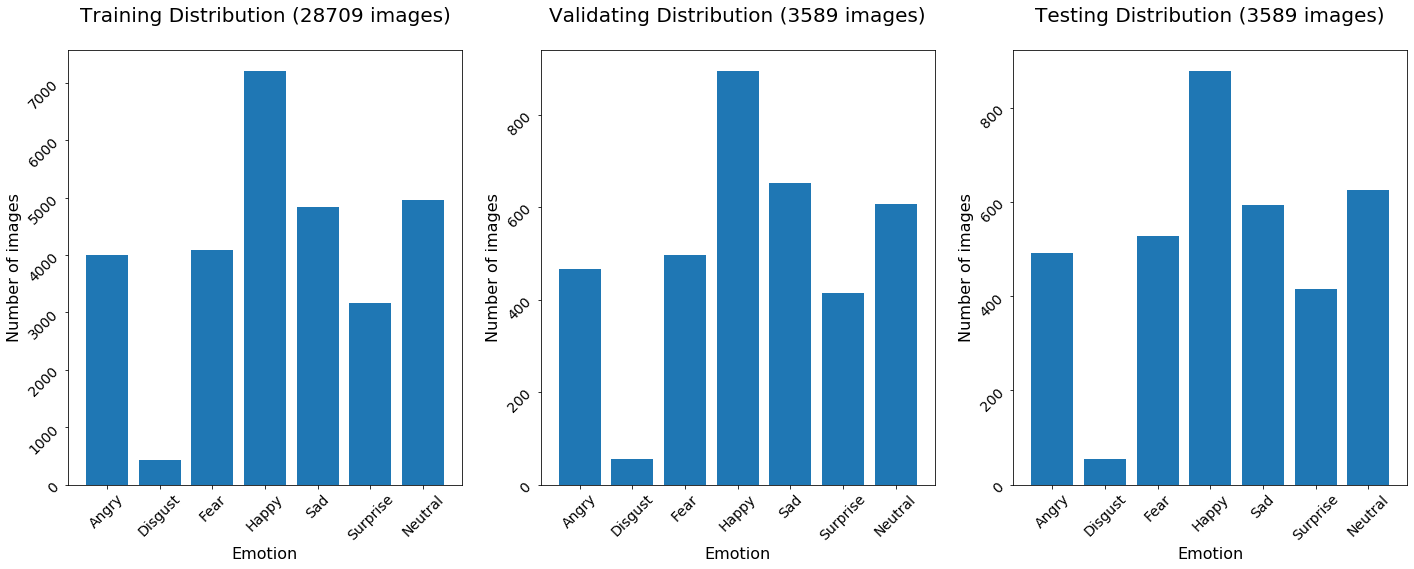

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, os
sns.set_theme(style="whitegrid")
labels = ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]
# Số ảnh tập Training theo lớp (thống kê chuẩn của FER2013; tổng = 28 709 và khớp biểu đồ ở trên)
train_counts = pd.Series([3995, 436, 4097, 7215, 4830, 3171, 4965], index=labels)
print("Tổng:", train_counts.sum()); print((train_counts/train_counts.sum()*100).round(1).to_string())
print(f"\nTỉ lệ lớp lớn nhất / nhỏ nhất = {train_counts.max()/train_counts.min():.1f} lần")
print(f"Baseline 'luôn đoán Happy' ≈ {train_counts.max()/train_counts.sum()*100:.1f}% accuracy")

Tổng: 28709
Angry       13.9
Disgust      1.5
Fear        14.3
Happy       25.1
Sad         16.8
Surprise    11.0
Neutral     17.3

Tỉ lệ lớp lớn nhất / nhỏ nhất = 16.5 lần
Baseline 'luôn đoán Happy' ≈ 25.1% accuracy


**Nhận xét**
- **Mất cân bằng mạnh**: *Disgust* chỉ ~1.5% (436 ảnh), *Happy* ~25%. Tỉ lệ lớn/nhỏ ≈ 16.5 lần → accuracy tổng thể có thể che giấu việc mô hình làm kém ở lớp hiếm; cần xem recall từng lớp.
- Baseline "luôn đoán Happy" cho ~25% → các run có val_acc ≈ 24.9% (xuất hiện trong bảng thí nghiệm) thực chất là **mô hình sụp đổ về đoán lớp đa số**.
- Tập valid/test có cùng hình dạng phân phối với train (stratified tương tự) → so sánh công bằng.

## 3. Chuẩn bị dữ liệu 
| Thành phần | Cấu hình trong code |
|---|---|
| Đọc dữ liệu | `pixels` → mảng 48×48, lưu `train/valid/test.npz` |
| Resize | 48 → **96** hoặc **128** (nội suy) và nhân 3 kênh để dùng trọng số ImageNet |
| Tiền xử lý theo mô hình | VGG16/ResNet50: kiểu *caffe* (BGR, trừ mean ImageNet); InceptionV3: kiểu *tf* (chuẩn hóa về [−1, 1]) |
| Data augmentation (train) | `Resize(+5px) → CenterCrop → Keras augment` (xoay tới **40°**, dịch 10% ngang/dọc, …) qua thư viện Albumentations; **valid/test không augment** ✔ |
| Mô hình | Backbone (VGG16 / ResNet50 / InceptionV3, có hoặc không trọng số ImageNet) → Dropout 0.1 → Dense 2048 → Dropout 0.1 → Dense 7 (softmax, L2 = 1e-4) |
| Loss / Metric | categorical cross-entropy / accuracy |
| Optimizer | SGD (lr 4e-4, momentum 0.9, Nesterov, decay 1e-6) hoặc Adam (lr 4e-4); tùy chọn **Cyclical LR** (1e-4 ↔ 4e-3) |
| Kiểm soát huấn luyện | `ModelCheckpoint(monitor=val_accuracy, save_best_only)`, `EarlyStopping(patience=30)`, tối đa 1000 epoch |

## 4. Đánh giá thuật toán – phân tích 34 thí nghiệm

In [2]:
ROOT = next(d for d in [".", "Fer13", "fer13_demo/Fer13", "fer13_demo/fer13_demo/Fer13"] if os.path.exists(f"{d}/experiments.xlsx"))
raw = pd.read_excel(f"{ROOT}/experiments.xlsx", header=None)
h = raw.index[raw.iloc[:,0]=="No"][0]
df = raw.iloc[h+1:, :10].copy(); df.columns = raw.iloc[h, :10].tolist(); df = df.dropna(subset=["model_name"]).reset_index(drop=True)
df["val_acc"]    = df["val_acc"].astype(float)
df["size"]       = df["image_size"].str.split(",").str[0].astype(int)
df["pretrained"] = df["model_name"].str.startswith("imagenet")
df["arch"]       = df["model_name"].str.replace("imagenet_","").str.replace("inceptionv3","inception_v3")
df["clr"]        = df["clr"].notna()
df = df[["No","arch","pretrained","size","optimizer","clr","val_acc"]]
print(len(df), "thí nghiệm"); display(df.sort_values("val_acc", ascending=False).head(8).reset_index(drop=True))

34 thí nghiệm


,No,arch,pretrained,size,optimizer,clr,val_acc
0,32,resnet50,True,128,sgd,True,70.97
1,28,vgg16,True,128,sgd,True,70.66
2,25,vgg16,True,96,sgd,True,70.10
3,29,vgg16,False,128,sgd,True,69.91
4,34,inception_v3,True,128,sgd,True,69.57
5,26,vgg16,False,96,sgd,True,69.02
6,4,inception_v3,True,96,sgd,True,68.90
7,31,resnet50,True,96,sgd,True,68.88


### 4.1 Kích thước ảnh

       n   mean    max
size                  
48    16  55.12  65.70
96    12  64.38  70.10
128    6  69.55  70.97


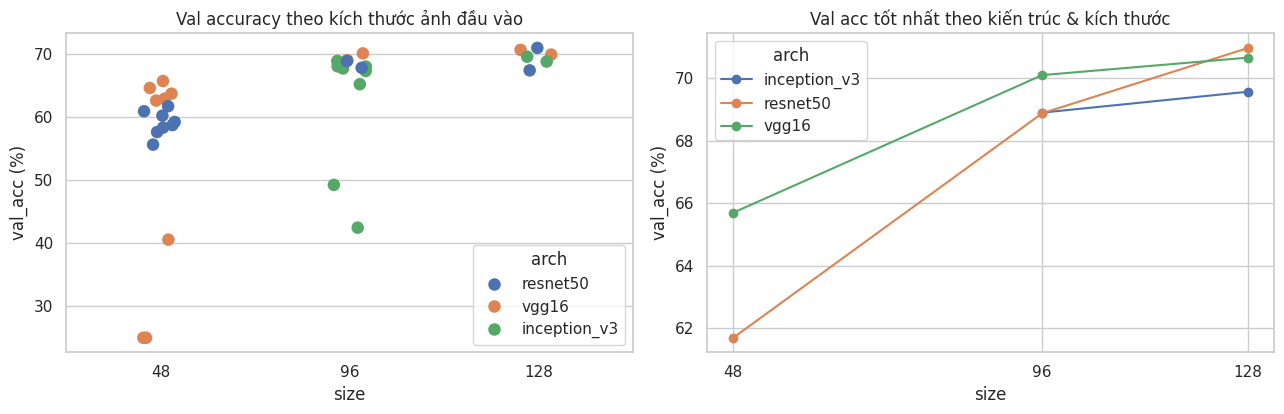

In [3]:
print(df.groupby("size").val_acc.agg(n="count", mean="mean", max="max").round(2))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
sns.stripplot(data=df, x="size", y="val_acc", hue="arch", s=9, ax=ax[0]); ax[0].set_title("Val accuracy theo kích thước ảnh đầu vào"); ax[0].set_ylabel("val_acc (%)")
best = df.groupby(["arch","size"]).val_acc.max().unstack(); best.T.plot(marker="o", ax=ax[1]); ax[1].set_title("Val acc tốt nhất theo kiến trúc & kích thước"); ax[1].set_ylabel("val_acc (%)"); ax[1].set_xticks([48,96,128])
plt.tight_layout(); plt.show()

### 4.2 Optimizer (SGD vs Adam) và Cyclical LR – so sánh **cùng điều kiện** ở 48×48

n   mean   min   max
optimizer clr                        
adam      False  4  51.90  24.9  62.6
          True   4  46.18  24.9  61.7
sgd       False  4  60.12  55.6  63.7
          True   4  62.30  58.7  65.7

Các run 'sụp đổ' (val_acc < 45%):


,No,arch,pretrained,size,optimizer,clr,val_acc
24,13,vgg16,False,48,adam,False,24.9
13,12,vgg16,False,48,adam,True,24.9
7,8,vgg16,True,48,adam,True,40.5
2,3,inception_v3,True,96,adam,True,42.4


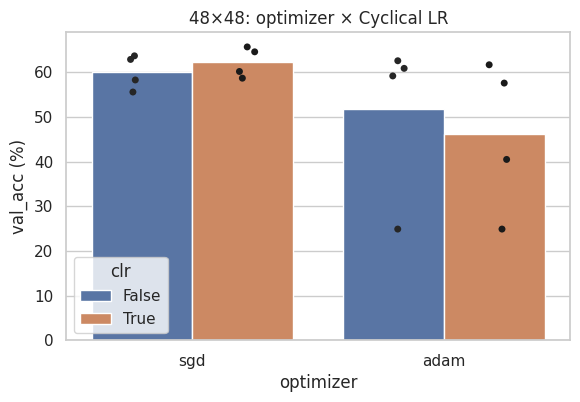

In [4]:
d48 = df[df["size"]==48]
tab = d48.groupby(["optimizer","clr"]).val_acc.agg(n="count", mean="mean", min="min", max="max").round(2); display(tab)
print("Các run 'sụp đổ' (val_acc < 45%):"); display(df[df.val_acc<45].sort_values("val_acc"))
plt.figure(figsize=(6.5,4)); sns.barplot(data=d48, x="optimizer", y="val_acc", hue="clr", errorbar=None); sns.stripplot(data=d48, x="optimizer", y="val_acc", hue="clr", dodge=True, color="k", legend=False)
plt.title("48×48: optimizer × Cyclical LR"); plt.ylabel("val_acc (%)"); plt.show()

### 4.3 Có trọng số ImageNet (pretrained) hay huấn luyện từ đầu? – ghép cặp cùng kiến trúc/kích thước/optimizer/CLR

In [5]:
pair = df.pivot_table(index=["arch","size","optimizer","clr"], columns="pretrained", values="val_acc", aggfunc="max").dropna()
pair.columns = ["scratch","pretrained"]; pair["gain (pretrained - scratch)"] = (pair.pretrained - pair.scratch).round(2)
display(pair.reset_index().sort_values(["size","arch"]))
g = pair.reset_index(); g["collapsed"] = (g.scratch<45) | (g.pretrained<45)       # cặp có run sụp đổ (chỉ đoán lớp đa số)
g["size_group"] = np.where(g["size"]==48, "48px", ">=96px"); gain = "gain (pretrained - scratch)"
print("Trung bình THÔ (bị méo bởi run sụp đổ):"); print(g.groupby("size_group")[gain].agg(["count","mean"]).round(2))
ok = g[~g.collapsed]
print("\nSau khi loại các cặp có run sụp đổ:")
print(ok.groupby("size_group")[gain].agg(n="count", mean="mean", median="median", n_positive=lambda x: int((x>0).sum())).round(2))
print("\nChỉ cấu hình ổn định SGD + CLR:")
print(ok[(ok.optimizer=="sgd") & ok.clr].groupby("size_group")[gain].agg(n="count", mean="mean", n_positive=lambda x: int((x>0).sum())).round(2))

,arch,size,optimizer,clr,scratch,pretrained,gain (pretrained - scratch)
5,resnet50,48,adam,False,60.90,59.20,-1.70
6,resnet50,48,adam,True,61.70,57.60,-4.10
7,resnet50,48,sgd,False,55.60,58.30,2.70
8,resnet50,48,sgd,True,60.20,58.70,-1.50
11,vgg16,48,adam,False,24.90,62.60,37.70
12,vgg16,48,adam,True,24.90,40.50,15.60
13,vgg16,48,sgd,False,63.70,62.90,-0.80
14,vgg16,48,sgd,True,65.70,64.60,-1.10
0,inception_v3,96,adam,False,68.04,67.30,-0.74
1,inception_v3,96,adam,True,49.20,42.40,-6.80


Trung bình THÔ (bị méo bởi run sụp đổ):
            count  mean
size_group             
48px            8  5.85
>=96px          9  0.35

Sau khi loại các cặp có run sụp đổ:
            n  mean  median  n_positive
size_group                             
48px        6 -1.08   -1.30           1
>=96px      8  1.24    0.99           7

Chỉ cấu hình ổn định SGD + CLR:
            n  mean  n_positive
size_group                     
48px        2 -1.30           0
>=96px      6  1.36           6


### Nhận xét từ phân tích thí nghiệm
1. **Kích thước ảnh là yếu tố tác động lớn nhất**: trung bình val_acc tăng từ ~55% (48px) → ~64% (96px) → ~70% (128px); mô hình tốt nhất đều ở 128px. Lý do: các backbone ImageNet được thiết kế cho ảnh lớn, ảnh 48px làm feature map ở các tầng sâu co lại gần như 1×1.
2. **SGD ≫ Adam ở thiết lập này**: ở 48px, SGD đạt ~60–62% còn Adam chỉ ~46–52%, kèm nhiều run sụp đổ (val_acc 24.9% ≈ tỉ lệ lớp Happy). Adam + Cyclical LR là tổ hợp tệ nhất (mean thấp nhất); SGD + CLR nhỉnh hơn SGD thường ~2 điểm.
3. **Pretrained (ImageNet): có lợi nhưng khiêm tốn, và chỉ rõ khi ảnh đủ lớn.** Với cấu hình ổn định **SGD + CLR ở ≥96px, cả 6/6 cặp đều dương**, từ +0.75 đến +3.57 điểm (rõ nhất ResNet50 128px). Ở **48px thì không nhất quán**: trong các cặp không sụp đổ có 5/6 cặp âm (khoảng −0.8 đến −4.1). Cẩn thận với "mức tăng trung bình thô" ở 48px (+5.85): con số này bị **méo bởi 2 run Adam huấn luyện từ đầu bị sụp đổ** (24.9%) tạo ra "gain" +37.7 và +15.6 – đó không phải lợi ích thật của ImageNet mà là Adam không ổn định. Ở ≥96px với Adam, pretrained cũng không giúp (−0.74, −6.8).
4. **Cảnh báo thống kê**: mỗi ô chỉ là **1 lần chạy (1 seed)**, và sai số chuẩn của accuracy trên tập valid 3 589 ảnh đã ~±0.8 điểm. Do đó các chênh lệch < 1 điểm (vd. ResNet50 70.97 vs VGG16 70.66) **không đủ cơ sở để kết luận** kiến trúc nào hơn; còn các hiệu ứng lớn (kích thước ảnh, SGD vs Adam) thì đáng tin.
5. Các yếu tố bị **gộp lẫn (confounded)**: các run 96/128px hầu hết đều dùng SGD+CLR, nên không tách riêng được tác động của CLR ở ảnh lớn. Muốn kết luận chặt cần thiết kế thí nghiệm lưới đầy đủ và lặp nhiều seed.

## 5. Trình bày kết quả

**Mô hình tốt nhất** (No. 32): `imagenet_resnet50`, 128×128×3, SGD (Nesterov) + Cyclical LR, FC 2048, dropout 0.1 → **valid 70.97%**, **test 71.30%**.

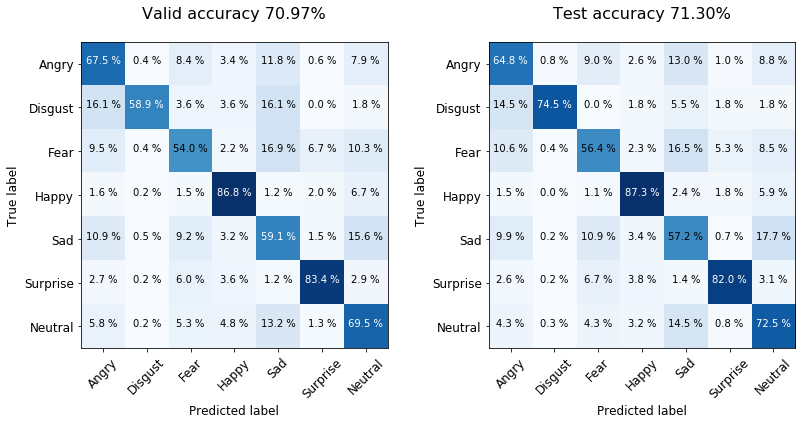

,valid,test,test_support(~)
Angry,67.5,64.8,491
Disgust,58.9,74.5,55
Fear,54.0,56.4,528
Happy,86.8,87.3,879
Sad,59.1,57.2,594
Surprise,83.4,82.0,416
Neutral,69.5,72.5,626


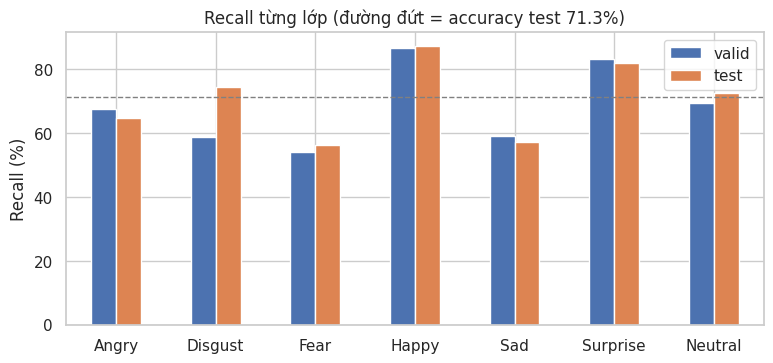

In [6]:
# Recall từng lớp – đọc từ confusion matrix (chuẩn hóa theo hàng) ở hình trên
rec = pd.DataFrame({"valid":[67.5,58.9,54.0,86.8,59.1,83.4,69.5], "test":[64.8,74.5,56.4,87.3,57.2,82.0,72.5]}, index=labels)
rec["test_support(~)"] = [491,55,528,879,594,416,626]   # số ảnh PrivateTest mỗi lớp (thống kê chuẩn FER2013)
display(rec)
rec[["valid","test"]].plot.bar(figsize=(9,3.8)); plt.axhline(71.3, ls="--", c="gray", lw=1); plt.ylabel("Recall (%)"); plt.title("Recall từng lớp (đường đứt = accuracy test 71.3%)"); plt.xticks(rotation=0); plt.show()

### Kết luận
- **Kết quả**: 71.3% trên test (PrivateTest), cao hơn nhiều so với baseline 25% (đoán lớp đa số) và ở mức cạnh tranh so với mức ~65% của con người theo bài báo gốc – đây là con số đáng tin hơn 70.97% valid vì valid đã được dùng để chọn checkpoint.
- **Điểm mạnh/yếu theo lớp**: *Happy* (≈87%) và *Surprise* (≈82–83%) dễ nhất; **Fear (≈54–56%) và Sad (≈57–59%) khó nhất** – hai lớp này hay bị nhầm với nhau và với Angry/Neutral (xem các ô ngoài đường chéo). *Disgust* recall test 74.5% nhưng chỉ dựa trên ~55 ảnh nên **rất không ổn định** (valid chỉ 58.9%) – đừng diễn giải quá mức.
- **Bài học quy trình**: (1) tách valid/test rõ ràng và báo cáo số test; (2) luôn xem kết quả theo lớp khi dữ liệu mất cân bằng; (3) ghi lại thí nghiệm có hệ thống như `experiments.xlsx` là thói quen tốt – nên bổ sung seed, thời gian huấn luyện và macro-F1; (4) chênh lệch < 1 điểm giữa các cấu hình chưa có ý nghĩa thống kê.